# I - Análise de Qualidade do Ar - CO (2016) em Seattle

Este projeto realiza uma análise exploratória dos dados de monóxido de carbono (CO) no ano de 2016.

Os dados foram obtidos da EPA (Environmental Protection Agency) e contêm medições diárias de poluição.

Objetivos:
- Analisar o comportamento do CO ao longo do tempo
- Identificar padrões e variações
- Visualizar tendências

Bibliotecas utilizadas:
- Pandas
- NumPy
- Matplotlib
- Seaborn

## II - Importação de Bibliotecas (OK)

In [17]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## III - Carregamento do Dataset - OK

In [11]:
df = pd.read_csv('daily_42101_2016.csv', low_memory=False)

df.head()

,State Code,County Code,Site Num,Parameter Code,POC,Latitude,Longitude,Datum,Parameter Name,Sample Duration,...,AQI,Method Code,Method Name,Local Site Name,Address,State Name,County Name,City Name,CBSA Name,Date of Last Change
0,1,73,23,42101,2,33.553056,-86.815,WGS84,Carbon monoxide,1 HOUR,...,NaN,554.0,INSTRUMENTAL - Gas Filter Correlation Thermo E...,North Birmingham,"NO. B'HAM,SOU R.R., 3009 28TH ST. NO.",Alabama,Jefferson,Birmingham,"Birmingham-Hoover, AL",2021-11-08
1,1,73,23,42101,2,33.553056,-86.815,WGS84,Carbon monoxide,1 HOUR,...,NaN,554.0,INSTRUMENTAL - Gas Filter Correlation Thermo E...,North Birmingham,"NO. B'HAM,SOU R.R., 3009 28TH ST. NO.",Alabama,Jefferson,Birmingham,"Birmingham-Hoover, AL",2021-11-08
2,1,73,23,42101,2,33.553056,-86.815,WGS84,Carbon monoxide,1 HOUR,...,NaN,554.0,INSTRUMENTAL - Gas Filter Correlation Thermo E...,North Birmingham,"NO. B'HAM,SOU R.R., 3009 28TH ST. NO.",Alabama,Jefferson,Birmingham,"Birmingham-Hoover, AL",2021-11-08
3,1,73,23,42101,2,33.553056,-86.815,WGS84,Carbon monoxide,1 HOUR,...,NaN,554.0,INSTRUMENTAL - Gas Filter Correlation Thermo E...,North Birmingham,"NO. B'HAM,SOU R.R., 3009 28TH ST. NO.",Alabama,Jefferson,Birmingham,"Birmingham-Hoover, AL",2021-11-08
4,1,73,23,42101,2,33.553056,-86.815,WGS84,Carbon monoxide,1 HOUR,...,NaN,554.0,INSTRUMENTAL - Gas Filter Correlation Thermo E...,North Birmingham,"NO. B'HAM,SOU R.R., 3009 28TH ST. NO.",Alabama,Jefferson,Birmingham,"Birmingham-Hoover, AL",2021-11-08


## IV - Exploração Inicial - OK

In [12]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209354 entries, 0 to 209353
Data columns (total 29 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   State Code           209354 non-null  int64  
 1   County Code          209354 non-null  int64  
 2   Site Num             209354 non-null  int64  
 3   Parameter Code       209354 non-null  int64  
 4   POC                  209354 non-null  int64  
 5   Latitude             209354 non-null  float64
 6   Longitude            209354 non-null  float64
 7   Datum                209354 non-null  object 
 8   Parameter Name       209354 non-null  object 
 9   Sample Duration      209354 non-null  object 
 10  Pollutant Standard   209354 non-null  object 
 11  Date Local           209354 non-null  object 
 12  Units of Measure     209354 non-null  object 
 13  Event Type           5338 non-null    object 
 14  Observation Count    209354 non-null  int64  
 15  Observation Perce

In [22]:
df.columns

Index(['State Code', 'County Code', 'Site Num', 'Parameter Code', 'POC',
       'Latitude', 'Longitude', 'Datum', 'Parameter Name', 'Sample Duration',
       'Pollutant Standard', 'Date Local', 'Units of Measure', 'Event Type',
       'Observation Count', 'Observation Percent', 'Arithmetic Mean',
       '1st Max Value', '1st Max Hour', 'AQI', 'Method Code', 'Method Name',
       'Local Site Name', 'Address', 'State Name', 'County Name', 'City Name',
       'CBSA Name', 'Date of Last Change'],
      dtype='object')

## V - Filtragem dos Dados para Seattle - ok

In [13]:
df_seattle = df[df['City Name'] == 'Seattle']

df_seattle

,State Code,County Code,Site Num,Parameter Code,POC,Latitude,Longitude,Datum,Parameter Name,Sample Duration,...,AQI,Method Code,Method Name,Local Site Name,Address,State Name,County Name,City Name,CBSA Name,Date of Last Change
200517,53,33,30,42101,1,47.597222,-122.319722,WGS84,Carbon monoxide,1 HOUR,...,NaN,593.0,INSTRUMENTAL - Gas Filter Correlation Teledyne...,Seattle-10th & Weller,10th & Weller,Washington,King,Seattle,"Seattle-Tacoma-Bellevue, WA",2021-11-08
200518,53,33,30,42101,1,47.597222,-122.319722,WGS84,Carbon monoxide,1 HOUR,...,NaN,593.0,INSTRUMENTAL - Gas Filter Correlation Teledyne...,Seattle-10th & Weller,10th & Weller,Washington,King,Seattle,"Seattle-Tacoma-Bellevue, WA",2021-11-08
200519,53,33,30,42101,1,47.597222,-122.319722,WGS84,Carbon monoxide,1 HOUR,...,NaN,593.0,INSTRUMENTAL - Gas Filter Correlation Teledyne...,Seattle-10th & Weller,10th & Weller,Washington,King,Seattle,"Seattle-Tacoma-Bellevue, WA",2021-11-08
200520,53,33,30,42101,1,47.597222,-122.319722,WGS84,Carbon monoxide,1 HOUR,...,NaN,593.0,INSTRUMENTAL - Gas Filter Correlation Teledyne...,Seattle-10th & Weller,10th & Weller,Washington,King,Seattle,"Seattle-Tacoma-Bellevue, WA",2021-11-08
200521,53,33,30,42101,1,47.597222,-122.319722,WGS84,Carbon monoxide,1 HOUR,...,NaN,593.0,INSTRUMENTAL - Gas Filter Correlation Teledyne...,Seattle-10th & Weller,10th & Weller,Washington,King,Seattle,"Seattle-Tacoma-Bellevue, WA",2021-11-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201819,53,33,80,42101,2,47.568236,-122.308628,WGS84,Carbon monoxide,8-HR RUN AVG END HOUR,...,2.0,593.0,INSTRUMENTAL - Gas Filter Correlation Teledyne...,SEATTLE - BEACON HILL,4103 BEACON HILL S,Washington,King,Seattle,"Seattle-Tacoma-Bellevue, WA",2023-02-05
201820,53,33,80,42101,2,47.568236,-122.308628,WGS84,Carbon monoxide,8-HR RUN AVG END HOUR,...,3.0,593.0,INSTRUMENTAL - Gas Filter Correlation Teledyne...,SEATTLE - BEACON HILL,4103 BEACON HILL S,Washington,King,Seattle,"Seattle-Tacoma-Bellevue, WA",2023-02-05
201821,53,33,80,42101,2,47.568236,-122.308628,WGS84,Carbon monoxide,8-HR RUN AVG END HOUR,...,3.0,593.0,INSTRUMENTAL - Gas Filter Correlation Teledyne...,SEATTLE - BEACON HILL,4103 BEACON HILL S,Washington,King,Seattle,"Seattle-Tacoma-Bellevue, WA",2023-02-05
201822,53,33,80,42101,2,47.568236,-122.308628,WGS84,Carbon monoxide,8-HR RUN AVG END HOUR,...,5.0,593.0,INSTRUMENTAL - Gas Filter Correlation Teledyne...,SEATTLE - BEACON HILL,4103 BEACON HILL S,Washington,King,Seattle,"Seattle-Tacoma-Bellevue, WA",2023-02-05


## VI - Seleção de medições de 8 horas - Ok

In [14]:
df_seattle = df_seattle[df_seattle['Sample Duration'] == '8-HR RUN AVG END HOUR']

df_seattle

,State Code,County Code,Site Num,Parameter Code,POC,Latitude,Longitude,Datum,Parameter Name,Sample Duration,...,AQI,Method Code,Method Name,Local Site Name,Address,State Name,County Name,City Name,CBSA Name,Date of Last Change
200803,53,33,30,42101,1,47.597222,-122.319722,WGS84,Carbon monoxide,8-HR RUN AVG END HOUR,...,13.0,593.0,INSTRUMENTAL - Gas Filter Correlation Teledyne...,Seattle-10th & Weller,10th & Weller,Washington,King,Seattle,"Seattle-Tacoma-Bellevue, WA",2023-02-05
200804,53,33,30,42101,1,47.597222,-122.319722,WGS84,Carbon monoxide,8-HR RUN AVG END HOUR,...,15.0,593.0,INSTRUMENTAL - Gas Filter Correlation Teledyne...,Seattle-10th & Weller,10th & Weller,Washington,King,Seattle,"Seattle-Tacoma-Bellevue, WA",2023-02-05
200805,53,33,30,42101,1,47.597222,-122.319722,WGS84,Carbon monoxide,8-HR RUN AVG END HOUR,...,11.0,593.0,INSTRUMENTAL - Gas Filter Correlation Teledyne...,Seattle-10th & Weller,10th & Weller,Washington,King,Seattle,"Seattle-Tacoma-Bellevue, WA",2023-02-05
200806,53,33,30,42101,1,47.597222,-122.319722,WGS84,Carbon monoxide,8-HR RUN AVG END HOUR,...,8.0,593.0,INSTRUMENTAL - Gas Filter Correlation Teledyne...,Seattle-10th & Weller,10th & Weller,Washington,King,Seattle,"Seattle-Tacoma-Bellevue, WA",2023-02-05
200807,53,33,30,42101,1,47.597222,-122.319722,WGS84,Carbon monoxide,8-HR RUN AVG END HOUR,...,13.0,593.0,INSTRUMENTAL - Gas Filter Correlation Teledyne...,Seattle-10th & Weller,10th & Weller,Washington,King,Seattle,"Seattle-Tacoma-Bellevue, WA",2023-02-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201819,53,33,80,42101,2,47.568236,-122.308628,WGS84,Carbon monoxide,8-HR RUN AVG END HOUR,...,2.0,593.0,INSTRUMENTAL - Gas Filter Correlation Teledyne...,SEATTLE - BEACON HILL,4103 BEACON HILL S,Washington,King,Seattle,"Seattle-Tacoma-Bellevue, WA",2023-02-05
201820,53,33,80,42101,2,47.568236,-122.308628,WGS84,Carbon monoxide,8-HR RUN AVG END HOUR,...,3.0,593.0,INSTRUMENTAL - Gas Filter Correlation Teledyne...,SEATTLE - BEACON HILL,4103 BEACON HILL S,Washington,King,Seattle,"Seattle-Tacoma-Bellevue, WA",2023-02-05
201821,53,33,80,42101,2,47.568236,-122.308628,WGS84,Carbon monoxide,8-HR RUN AVG END HOUR,...,3.0,593.0,INSTRUMENTAL - Gas Filter Correlation Teledyne...,SEATTLE - BEACON HILL,4103 BEACON HILL S,Washington,King,Seattle,"Seattle-Tacoma-Bellevue, WA",2023-02-05
201822,53,33,80,42101,2,47.568236,-122.308628,WGS84,Carbon monoxide,8-HR RUN AVG END HOUR,...,5.0,593.0,INSTRUMENTAL - Gas Filter Correlation Teledyne...,SEATTLE - BEACON HILL,4103 BEACON HILL S,Washington,King,Seattle,"Seattle-Tacoma-Bellevue, WA",2023-02-05


## VII - Limpeza dos Dados

In [15]:
df_seattle.isnull().sum()

State Code               0
County Code              0
Site Num                 0
Parameter Code           0
POC                      0
Latitude                 0
Longitude                0
Datum                    0
Parameter Name           0
Sample Duration          0
Pollutant Standard       0
Date Local               0
Units of Measure         0
Event Type             655
Observation Count        0
Observation Percent      0
Arithmetic Mean          0
1st Max Value            0
1st Max Hour             0
AQI                      0
Method Code              0
Method Name              0
Local Site Name          0
Address                  0
State Name               0
County Name              0
City Name                0
CBSA Name                0
Date of Last Change      0
dtype: int64

In [16]:
df_seattle = df_seattle.dropna()

df_seattle

In [27]:
### Conversão da coluna de data

In [60]:
df_seattle['Date Local'] = pd.to_datetime(df_seattle['Date Local'])

df_seattle

## VIII - Estatísticas Descritivas

In [61]:
df_seattle['Arithmetic Mean'].mean()

df_seattle

nan

In [62]:
df_seattle['Arithmetic Mean'].median()

df_seattle

nan

In [63]:
df_seattle['Arithmetic Mean'].std()

df_seattle

nan

## IX - Evolução ao Longo do Tempo

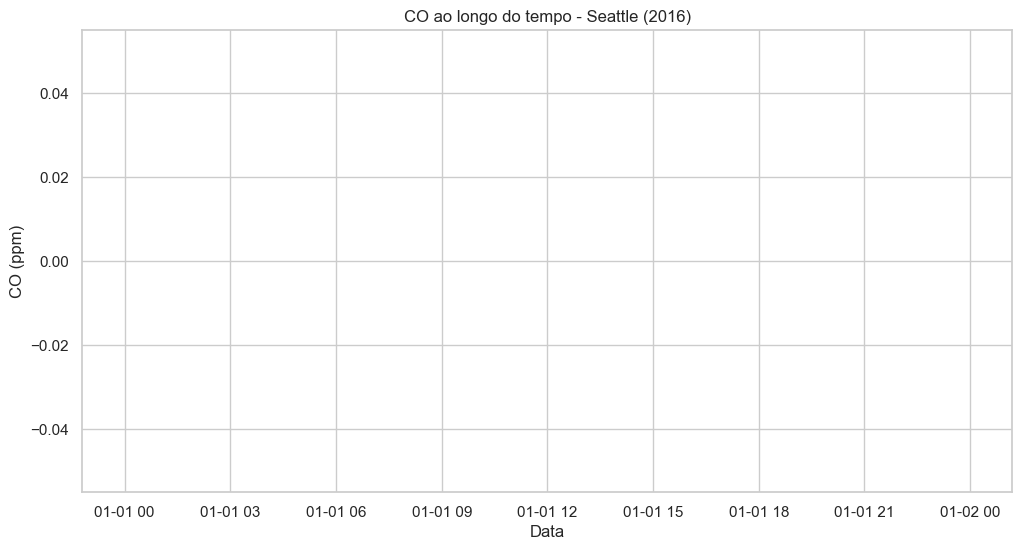

In [64]:

plt.figure(figsize=(12,6))
plt.plot(df_seattle['Date Local'], df_seattle['Arithmetic Mean'])
plt.title('CO ao longo do tempo - Seattle (2016)')
plt.xlabel('Data')
plt.ylabel('CO (ppm)')
plt.show()

## X - Distribuição dos Valores de CO

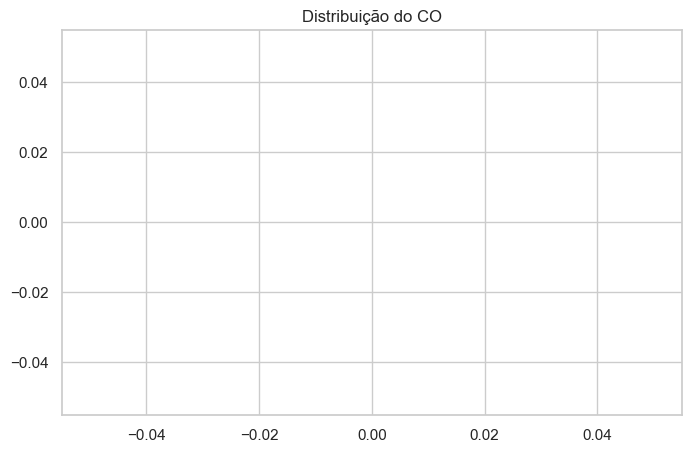

In [65]:

plt.figure(figsize=(8,5))
sns.histplot(df_seattle['Arithmetic Mean'], kde=True)
plt.title('Distribuição do CO')
plt.show()

## XI - Análise por Mês

In [66]:

df_seattle['Month'] = df_seattle['Date Local'].dt.month

monthly_avg = df_seattle.groupby('Month')['Arithmetic Mean'].mean()

monthly_avg

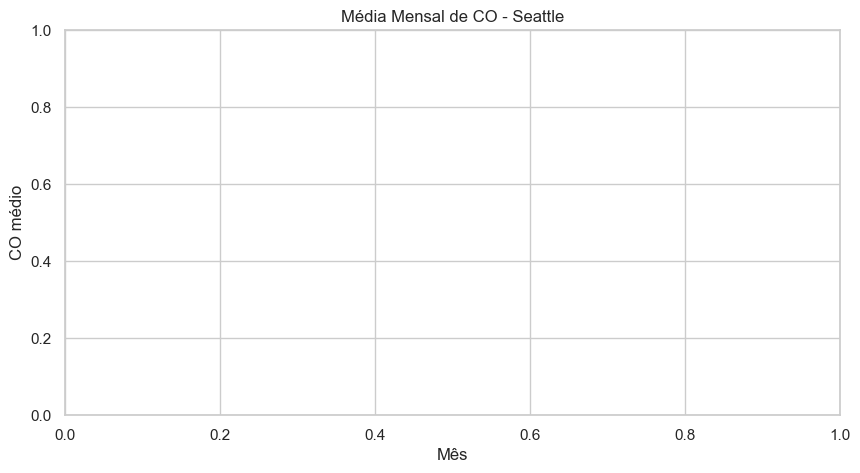

In [67]:

plt.figure(figsize=(10,5))
sns.lineplot(x=monthly_avg.index, y=monthly_avg.values)
plt.title('Média Mensal de CO - Seattle')
plt.xlabel('Mês')
plt.ylabel('CO médio')
plt.show()


## XII - Resultados


A análise dos dados de monóxido de carbono (CO) em Seattle no ano de 2016 revela:

- Os níveis médios de CO são relativamente baixos, indicando boa qualidade do ar na maior parte do tempo.
- Existem variações ao longo do ano, com alguns picos isolados que podem estar relacionados a maior fluxo de veículos ou condições climáticas.
- A análise temporal não mostra tendência crescente ou decrescente clara, indicando estabilidade geral.

Análise Mensal
- Observa-se que alguns meses apresentam níveis médios ligeiramente mais altos.
- Isso pode indicar influência sazonal, como inverno (maior emissão e menor dispersão de poluentes).

Possíveis Causas
- Tráfego urbano
- Condições meteorológicas (inversão térmica)
- Emissões locais

Conclusão
- A qualidade do ar em Seattle em 2016, considerando o CO, pode ser considerada estável e dentro de padrões aceitáveis, com variações pontuais que merecem atenção